# SI - Photonic coherence-based light generation (PCLG)

This notebook regenerates the data-driven camera and modal-weight panels (c-f) of the PCLG supplementary figure. The conceptual schematics in panels a-b were manually assembled and are retained in the reference PDF. The camera bundle contains the five arithmetic averages used by the analysis rather than the 505 individual frames.

In [1]:
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np


def find_repository_root():
    for candidate in (Path.cwd(), *Path.cwd().parents):
        if (candidate / "data").is_dir() and (candidate / "notebooks").is_dir():
            return candidate
    raise FileNotFoundError("Run this notebook from inside the reproduction repository.")


ROOT = find_repository_root()
PNG_DIR = ROOT / "figures" / "png"
SVG_DIR = ROOT / "figures" / "svg"
PNG_DIR.mkdir(parents=True, exist_ok=True)
SVG_DIR.mkdir(parents=True, exist_ok=True)


def save_figure(fig, filename):
    """Save matching raster and vector copies of a figure."""
    fig.savefig(PNG_DIR / f"{filename}.png", dpi=300, bbox_inches="tight")
    fig.savefig(SVG_DIR / f"{filename}.svg", bbox_inches="tight")

mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "Arial", "Nimbus Sans", "DejaVu Sans"],
    "font.size": 12,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.linewidth": 0.5,
    "xtick.major.width": 0.5,
    "ytick.major.width": 0.5,
    "axes.grid": False,
    "legend.frameon": False,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

import pandas as pd
from scipy import ndimage as ndi


## Load measurements, camera averages, and calibration

In [2]:
experiment = np.load(
    ROOT / "data" / "si_pclg" / "pclg_2026-02-04_16-55-08.npy", allow_pickle=True
).item()
camera = np.load(ROOT / "data" / "si_pclg" / "camera_averages.npz")
calibration_table = pd.read_csv(ROOT / "data" / "si_pclg" / "heater_calibration.csv")
calibration = calibration_table.set_index("channel")[["v_bar", "v_cross"]].to_dict("index")

reference_annotation = plt.imread(ROOT / "data" / "si_pclg" / "ref_avg_annotated.png")
reference_image = np.asarray(camera["ref"], dtype=float)
print("Averaged camera frame shape:", reference_image.shape)

Averaged camera frame shape: (512, 640)


## Recover the nine camera regions and their measured powers

In [3]:
def grayscale(image):
    image = np.asarray(image, dtype=float)
    if image.ndim == 3:
        image = 0.2126 * image[..., 0] + 0.7152 * image[..., 1] + 0.0722 * image[..., 2]
    return image


annotation_gray = grayscale(reference_annotation)
binary = annotation_gray >= 0.985
binary = ndi.binary_opening(binary, iterations=1)
binary = ndi.binary_closing(binary, iterations=1)
binary = ndi.binary_fill_holes(binary)
labels, count = ndi.label(binary)
areas = ndi.sum(np.ones_like(labels), labels, index=np.arange(1, count + 1))
components = np.argsort(areas)[::-1][:9] + 1

masks, centroids = [], []
for component in components:
    mask = ndi.binary_erosion(labels == component, iterations=5)
    masks.append(mask)
    rows, columns = np.where(mask)
    centroids.append((rows.mean(), columns.mean()))
order = sorted(range(9), key=lambda index: (centroids[index][0], centroids[index][1]))
masks = [masks[index] for index in order]
centroids = [centroids[index] for index in order]

# Map the image-space ordering to the chip input-port ordering used in the experiment.
permutation = [3, 1, 6, 0, 8, 4, 7, 2, 5]
masks = [masks[index] for index in permutation]
centroids = [centroids[index] for index in permutation]

intensity_sums = {
    name: np.array([grayscale(camera[name])[mask].sum() for mask in masks])
    for name in ("beam1", "beam2", "beam12", "beam2_layer1off")
}

def camera_distribution(name):
    values = intensity_sums[name][1:] - intensity_sums[name][0]
    return values / values.sum()

beam_1 = camera_distribution("beam1")
beam_2 = camera_distribution("beam2")
beam_12 = camera_distribution("beam12")
beam_2_layer1_off = camera_distribution("beam2_layer1off")

## Convert fitted heater powers to layer matrices

In [4]:
THETA_CHANNELS = {34, 36, 5, 10, 14, 18, 22, 26, 29, 31, 30, 32, 28, 25, 21, 17, 13, 9, 6}
LAYER_1_CHANNELS = [35, 34, 42, 36, 4, 5, 7, 10, 11, 14, 15, 18, 19, 22]
LAYER_2_CHANNELS = [43, 6, 8, 9, 12, 13, 16, 17, 20, 21, 24, 25]

def angle_from_power(channel, power):
    row = calibration[channel]
    return ((power - row["v_cross"]**2) * np.pi / (row["v_bar"]**2 - row["v_cross"]**2)) % (2*np.pi)

def one_mzi(size, index, theta, phi, kappa=np.pi/4, alpha=0):
    a = np.exp(1j*phi) * (np.cos(2*kappa)*np.cos(theta/2) + 1j*np.sin(theta/2))
    b = np.exp(1j*alpha) * np.sin(2*kappa) * np.cos(theta/2)
    c = -np.exp(1j*(phi-alpha)) * np.sin(2*kappa) * np.cos(theta/2)
    d = np.cos(2*kappa)*np.cos(theta/2) - 1j*np.sin(theta/2)
    block = np.exp(1j*theta/2) * np.array([[a, b], [c, d]])
    matrix = np.eye(size, dtype=complex)
    matrix[index:index+2, index:index+2] = block
    return matrix

def one_layer(thetas, phis):
    matrix = np.eye(len(thetas) + 1, dtype=complex)
    for index, (theta, phi) in enumerate(zip(thetas, phis)):
        matrix = matrix @ one_mzi(len(thetas) + 1, index, theta, phi)
    return matrix

def layer_matrix(channels, powers):
    theta, phi = [], []
    for channel, power in zip(channels, powers):
        (theta if channel in THETA_CHANNELS else phi).append(angle_from_power(channel, power))
    return one_layer(theta[::-1], phi[::-1])

layer_1_powers = np.asarray(experiment["optimization_layer_1"]["layer1"]["history"][-1][0][0], dtype=float)
layer_2_powers = np.asarray(experiment["optimization_layer_2"]["layer2"]["history"][-1][0][0], dtype=float)
layer_1 = layer_matrix(LAYER_1_CHANNELS, layer_1_powers)
layer_2 = layer_matrix(LAYER_2_CHANNELS, layer_2_powers)

eigenvalue_1 = experiment["optimization_layer_1"]["layer1"]["history_lockin"][-1]
eigenvalue_2 = experiment["optimization_layer_2"]["layer2"]["history_lockin"][-1]
diagonal = np.diag([eigenvalue_1, eigenvalue_2, *np.zeros(6)])
input_coherency = layer_1.conj().T @ diagonal @ layer_1
combined_from_mzi = np.abs(np.diag(input_coherency))
combined_from_mzi /= combined_from_mzi.sum()

## Plot the quantitative SI panels

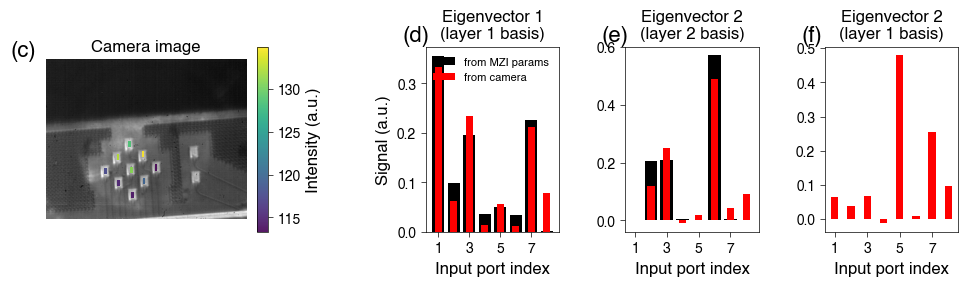

In [5]:
fig = plt.figure(figsize=(9.6, 2.8))
# Nest the camera/colorbar and the three bar panels so there is a deliberate
# gutter between the two vertical axis labels at journal-column scale.
outer = fig.add_gridspec(1, 2, width_ratios=(1.25, 3.0), wspace=0.42)
camera_grid = outer[0].subgridspec(1, 2, width_ratios=(1.0, 0.055), wspace=0.10)
bar_grid = outer[1].subgridspec(1, 3, wspace=0.50)

ax_camera = fig.add_subplot(camera_grid[0, 0])
ax_camera.imshow(grayscale(reference_image), cmap="gray")
# The published camera panel colors each detected port by its integrated
# intensity in the simultaneous two-beam exposure.  These are the same raw
# mask sums used to obtain the normalized red bars below.
camera_map_values = intensity_sums["beam12"]
filled = np.full(masks[0].shape, np.nan)
for mask, value in zip(masks, camera_map_values):
    filled[mask] = value
image = ax_camera.imshow(filled, cmap="viridis", alpha=0.9)
ax_camera.axis("off")
ax_camera.set_title("Camera image")
colorbar_axis = fig.add_subplot(camera_grid[0, 1])
colorbar = fig.colorbar(image, cax=colorbar_axis)
colorbar.set_label("Intensity (a.u.)")

bar_specs = [
    (np.abs(layer_1[0])**2, beam_1, "Eigenvector 1\n(layer 1 basis)"),
    (np.abs(layer_2[0])**2, beam_2_layer1_off, "Eigenvector 2\n(layer 2 basis)"),
    (None, beam_2, "Eigenvector 2\n(layer 1 basis)"),
]
bar_axes = []
for column, (mzi_values, camera_values, title) in enumerate(bar_specs):
    axis = fig.add_subplot(bar_grid[0, column])
    bar_axes.append(axis)
    ports = np.arange(1, 9)
    if mzi_values is not None:
        mzi_ports = ports if len(mzi_values) == 8 else np.arange(2, 9)
        axis.bar(mzi_ports, mzi_values, color="black", label="from MZI params")
    axis.bar(ports, camera_values, width=0.45, color="red", label="from camera")
    axis.set(title=title, xlabel="Input port index")
    axis.set_xticks([1, 3, 5, 7])
    if column == 0:
        axis.set_ylabel("Signal (a.u.)")
        axis.legend(fontsize=8)

for label, axis in zip("cdef", [ax_camera, *bar_axes]):
    axis.text(-0.18, 1.12, f"({label})", transform=axis.transAxes, fontsize=16, va="top")
fig.subplots_adjust(left=0.04, right=0.99, bottom=0.20, top=0.86)
save_figure(fig, "si_pclg_quantitative_panels")
plt.show()